# Assignment 3 (CSI 4142) [Part 2]

# Group Information

- **Student name**: Shabrina Sharmin
- **Student Id**: 300230297
- **Group no**: A-85

# Empirical study with Decision Tree Classifier

## Description of the dataset

The Diabetes prediction dataset is a collection of medical and demographic data from patients, along with their diabetes status (positive or negative). The data includes features such as age, gender, body mass index (BMI), hypertension, heart disease, smoking history, HbA1c level, and blood glucose level. This dataset can be used to build machine learning models to predict diabetes in patients based on their medical history and demographic information. This dataset can also be useful to heathcare professionals in identifying the patients who are at risk of developing diabetes.

A brief description of the feature description is provided below:

*   **gender(string):** refers to the biological sex of the individual, which can have an impact on their susceptibility to diabetes. This is a categorical feature.

*   **age(float64):** refers to the age of different individuals. This is a numerical feature.

*   **hypertension(int64):** refers to the blood pressure in the arteries is persistently elevated.
This is a numerical feature.

*   **smoking_history(string):** refers to the habit of the indivuduals which can be risk factor for diabetes. This is a categorical feature.


*   **bmi(float64):** BMI (Body Mass Index) is a measure of body fat based on weight and height. This is a numerical feature.
*   **HbA1c_level(float64):** HbA1c (Hemoglobin A1c) level is a measure of a person's average blood sugar level over the past 2-3 months. This is a numerical feature.

*   **blood_glucose_level(int64):** Blood glucose level refers to the amount of glucose in the bloodstream at a given time. This is a numerical feature.

*   **diabetes(string):** Diabetes is the target variable being predicted, with values of 1 indicating the presence of diabetes and 0 indicating the absence of diabetes. This is a categorical feature.





## **Access data**

### **Local instruction for accessing dataset on kaggle:** ###
**Pre-Requisite:** User must respectively create and download their access token from https://www.kaggle.com/. If the user already has an existing kaggle token, then no need to create a new one. Just use the existing kaggle token (kaggle.json) as requested.
If the "kaggle.json" token is not under ".kaggle" folder in the home path, then place the kaggle.json in the same directoy as the notebook. The code below will copy the "kaggle.json" token to the correct location

In [ ]:
# Create a kaggle configuration folder/directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json  # Adjust the permissions of the file.

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


### **Instruction for running in Google Colab** ###

Upon running the code in following section below, a prompt will pop up asking for the **'kaggle.json'** file. The user needs to click on the 'Choose file' option and navigate to the corresponding directory where the kaggle.json file should reside and choose **'kaggle.json'** file. At this point, the "kaggle.json" should be loaded to the instance of the colab.

In [ ]:
from os import mkdir

## Upload kaggle API credentials to Colab
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shabrinasharmin","key":"62fe625309926cb95271b826f7908041"}'}

### **Setting up the appropriate libraries needed for the assignment** ##
Run the follwing code below to set up the appropriate libraries that are needed

In [ ]:
## Install Kaggle library
!pip install -q kaggle
!pip install pandas
!pip install seaborn
!pip install matplotlib
!pip install numpy

### **Download the dataset**

In [ ]:
## Download the dataset 1
!kaggle datasets download -d iammustafatz/diabetes-prediction-dataset
## Unzip the dataset 1
!unzip diabetes-prediction-dataset.zip

# ## download dataset 2 (movies.csv)
# !kaggle datasets download -d bharatnatrayn/movies-dataset-for-feature-extracion-prediction
# ## unzip the dataset 2
# !unzip movies-dataset-for-feature-extracion-prediction.zip

Dataset URL: https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset
License(s): copyright-authors
  0% 0.00/734k [00:00<?, ?B/s]
100% 734k/734k [00:00<00:00, 42.6MB/s]
Archive:  diabetes-prediction-dataset.zip
  inflating: diabetes_prediction_dataset.csv  


## Imports

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import datetime
from datetime import datetime
from datetime import date
import re as re
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


## Read the files

In [17]:
# read the first dataset (dirty_cafe_sales>csv)
diabetes_prediction_dataset = pd.read_csv('diabetes_prediction_dataset.csv')
diabetes_prediction_dataset.head(20)
diabetes_prediction_dataset.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

## (a) Data Cleaning

### a. Data pre-pocessing

The dataset did not require data processing since it does not have nan/empty values. Type checkings for different columns has been conducted and no miss-matched types for any of the columns were found.

In [21]:

## ckeck data types to find potential pre-processing required
numerical_columns = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
categorical_columns = ['gender', 'smoking_history']

### expected type for parameters
expected_types = {
    'age': 'float64',
    'hypertension': 'int64',
    'heart_disease': 'int64',
    'bmi': 'float64',
    'HbA1c_level': 'float64',
    'blood_glucose_level': 'int64',
    'gender': 'object',
    'smoking_history': 'object'
}

### function to check type
def check_data_types(df, expected_types):
  error_type ={}
  for col, expected_type in expected_types.items():
    actual_type = df[col].dtype
    if str(actual_type) != expected_type:
      error_type[col] = f"Expected: {expected_type}, Found: {actual_type}"

  return error_type


### func to display type error
def display_type_error(data_type):
  if data_type:
    for column, error in data_type.items():
        print(f"Data type mismatch in column '{column}': {error}")
  else:
    print("All column data types are correct and are in correct formatting. Thus, no need for prepocessing!!!")

### call the fun for type checking
data_type = check_data_types(diabetes_prediction_dataset, expected_types)
display_type_error(data_type)


### drop the dulicate rows
diabetes_prediction_dataset.drop_duplicates(inplace=True)
diabetes_prediction_dataset.info()



All column data types are correct and are in correct formatting. Thus, no need for prepocessing!!!
<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  object 
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  object 
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.3+ MB


### b. Data imputation

No imputation required as well since the dataset does not contain nan/empty values.

In [22]:
### check for possible missing values to decide if imputation is needed
diabetes_prediction_dataset['gender'].isna().sum()
diabetes_prediction_dataset['age'].isna().sum()
diabetes_prediction_dataset['hypertension'].isna().sum()
diabetes_prediction_dataset['heart_disease'].isna().sum()
diabetes_prediction_dataset['smoking_history'].isna().sum()
diabetes_prediction_dataset['bmi'].isna().sum()
diabetes_prediction_dataset['HbA1c_level'].isna().sum()
diabetes_prediction_dataset['blood_glucose_level'].isna().sum()
diabetes_prediction_dataset['diabetes'].isna().sum()

print(" There are no missing values in the dataset. Thus, no need for imputation at this point")


 There are no missing values in the dataset. Thus, no need for imputation at this point


## (b) Features encoding

The categorical features ('gender', and 'smoking_history') has been encoded using one-hot encoding.
The numerical features has been bucketized as decisiontree classifier might be benefitted from the binnig of numerical features.

In [28]:
diabetes_prediction_dataset_encoded = diabetes_prediction_dataset.copy()
#diabetes_prediction_dataset_encoded.info()

numerical_columns = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
categorical_columns = ['gender', 'smoking_history']

diabetes_prediction_dataset_encoded.drop(diabetes_prediction_dataset_encoded[diabetes_prediction_dataset_encoded['gender'] == 'Other'].index, inplace = True)
### categorical features encoding using one hot encoding
diabetes_prediction_dataset_encoded = pd.get_dummies(diabetes_prediction_dataset_encoded, columns=categorical_columns)

print("######### dataframe after encoding ############")
diabetes_prediction_dataset_encoded.info()


### binnig certain numerical values
diabetes_prediction_dataset_encoded_binnig = diabetes_prediction_dataset_encoded.copy()

## bining for age
bins_age = [0,18,35,65,100]
labels_age = ["Child", "Young Adult", "Adult", "Senior"]
diabetes_prediction_dataset_encoded_binnig['age_group'] = pd.cut(diabetes_prediction_dataset_encoded_binnig['age'], bins=bins_age, labels=labels_age)
#diabetes_prediction_dataset_encoded_binnig.info()
## encode categorical binned col
diabetes_prediction_dataset_encoded_binnig = pd.get_dummies(diabetes_prediction_dataset_encoded_binnig, columns=['age_group'])
# diabetes_prediction_dataset_encoded_binnig.info()


## bining for BMI
bins_bmi = [0, 18.5, 24.9, 29.9, 100]
labels_bmi = ["Underweight", "Normal", "Overweight", "Obese"]
diabetes_prediction_dataset_encoded_binnig['bmi_group'] = pd.cut(diabetes_prediction_dataset_encoded_binnig['bmi'], bins=bins_bmi, labels=labels_bmi)
## encode the binned col
diabetes_prediction_dataset_encoded_binnig = pd.get_dummies(diabetes_prediction_dataset_encoded_binnig, columns=['bmi_group'])
# diabetes_prediction_dataset_encoded_binnig.info()


## bining for Blood Glucose
bins_blood_glucose = [0, 99, 125,float('inf')]
labels_blood_glucose = ["Normal", "Pre-diabetic", "Diabetic"]
diabetes_prediction_dataset_encoded_binnig['blood_glucose_level_group'] = pd.cut(diabetes_prediction_dataset_encoded_binnig['blood_glucose_level'], bins=bins_blood_glucose, labels=labels_blood_glucose)
## encode the binned col
diabetes_prediction_dataset_encoded_binnig = pd.get_dummies(diabetes_prediction_dataset_encoded_binnig, columns=['blood_glucose_level_group'])
# diabetes_prediction_dataset_encoded_binnig.info()


## bining for HbA1c Level
bins_hba1c = [0, 5.6, 6.4, float('inf')]
label_hba1c = ["Normal", "Pre-diabetic", "Diabetic"]
diabetes_prediction_dataset_encoded_binnig['HbA1c_level_group'] = pd.cut(diabetes_prediction_dataset_encoded_binnig['HbA1c_level'], bins=bins_hba1c, labels=label_hba1c)
## encode the binned col
diabetes_prediction_dataset_encoded_binnig = pd.get_dummies(diabetes_prediction_dataset_encoded_binnig, columns=['HbA1c_level_group'])
print("######### dataframe after binning ############")
diabetes_prediction_dataset_encoded_binnig.info()



######### dataframe after encoding ############
<class 'pandas.core.frame.DataFrame'>
Index: 96128 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          96128 non-null  float64
 1   hypertension                 96128 non-null  int64  
 2   heart_disease                96128 non-null  int64  
 3   bmi                          96128 non-null  float64
 4   HbA1c_level                  96128 non-null  float64
 5   blood_glucose_level          96128 non-null  int64  
 6   diabetes                     96128 non-null  int64  
 7   gender_Female                96128 non-null  bool   
 8   gender_Male                  96128 non-null  bool   
 9   smoking_history_No Info      96128 non-null  bool   
 10  smoking_history_current      96128 non-null  bool   
 11  smoking_history_ever         96128 non-null  bool   
 12  smoking_history_former       96

## (c) EDA and outlier detection

As LOF is costly to use (if large dataset), initially EDA has been used to visualize the data and find which feature LOF should be used on. Then the LOF has been applied to the plausible candidates for outlier detection.


### a. EDA for numeical and categorical features

Numerical featurs EDA


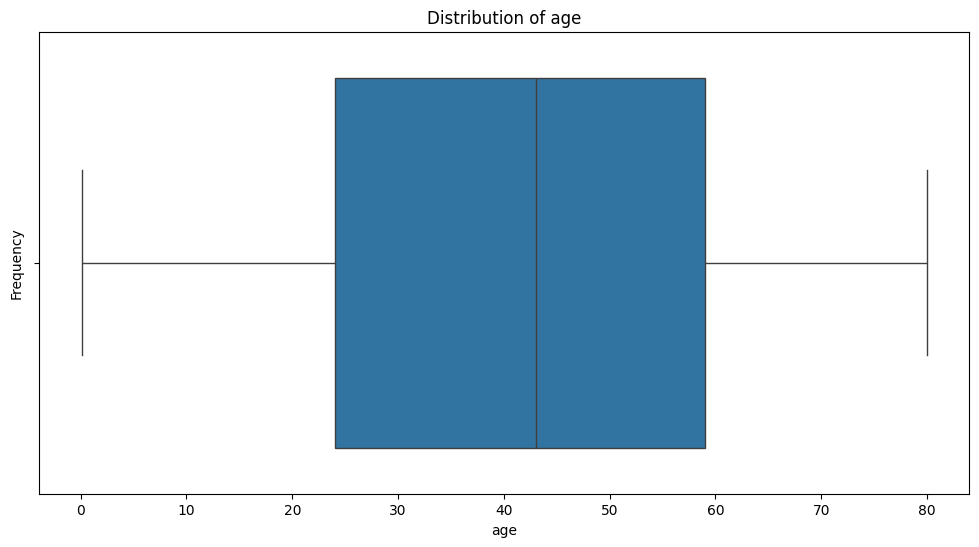

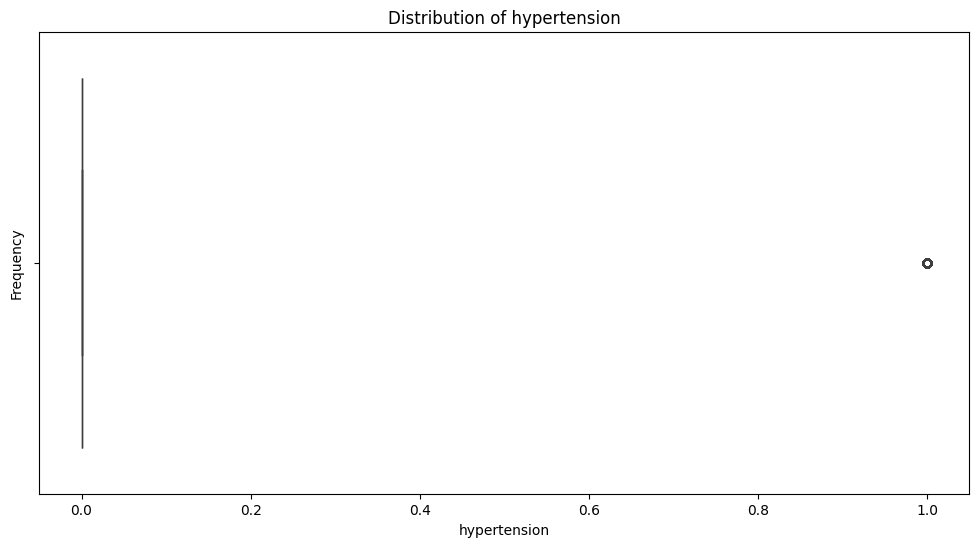

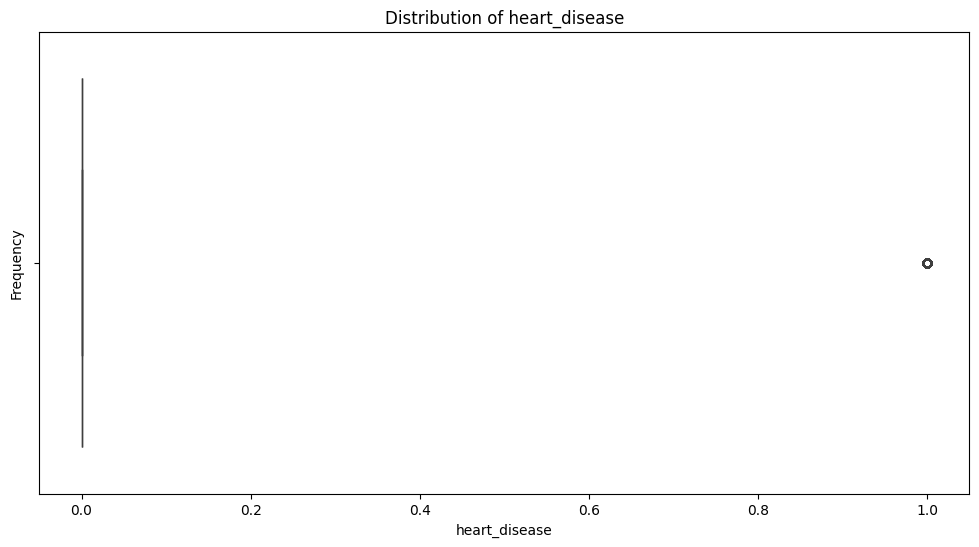

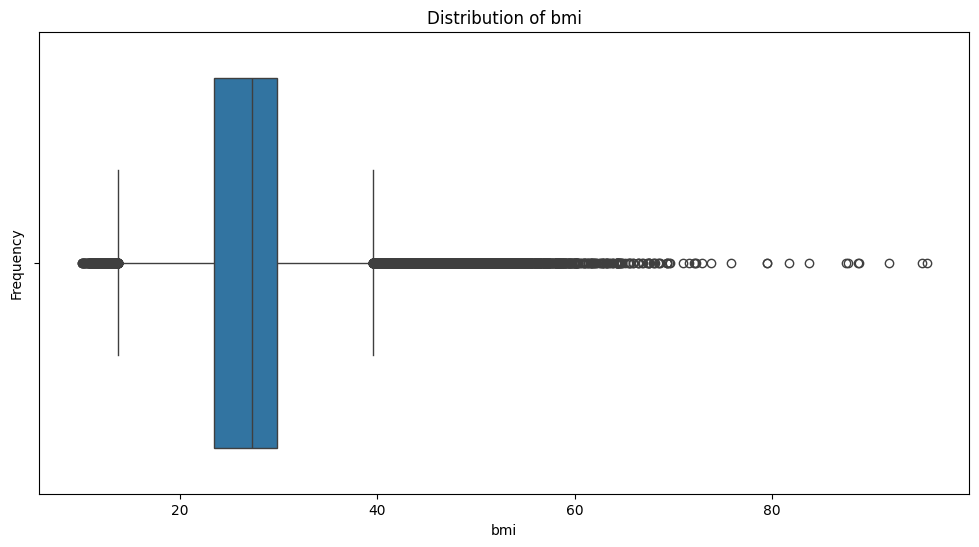

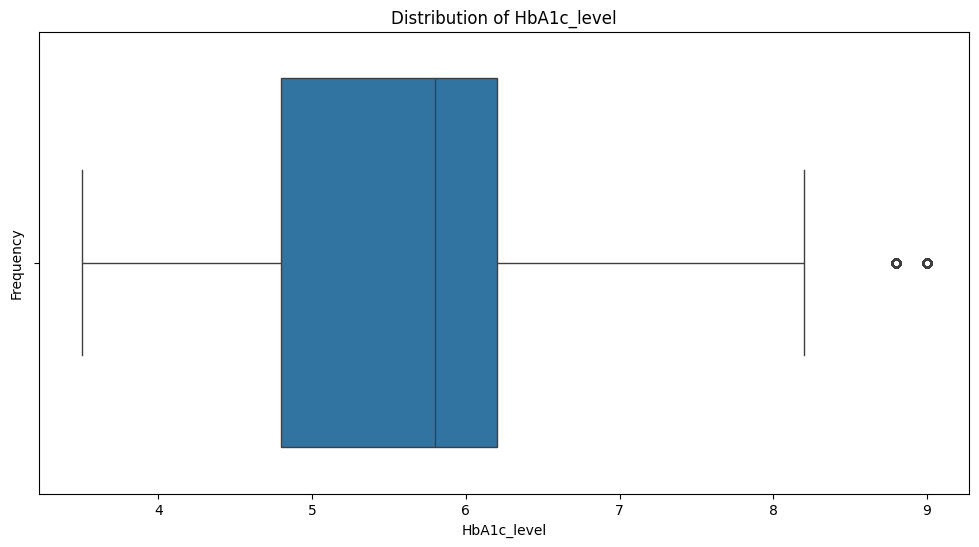

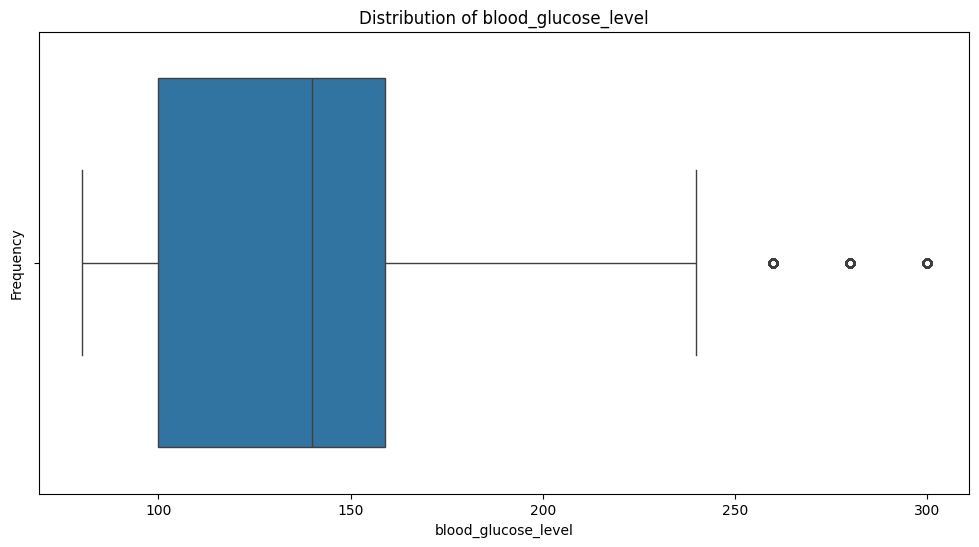

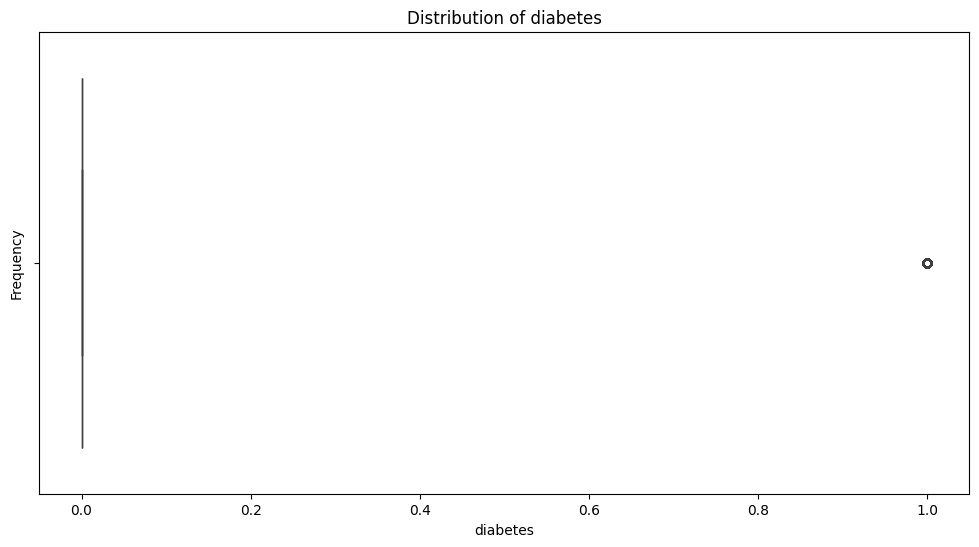

Categorical featurs EDA


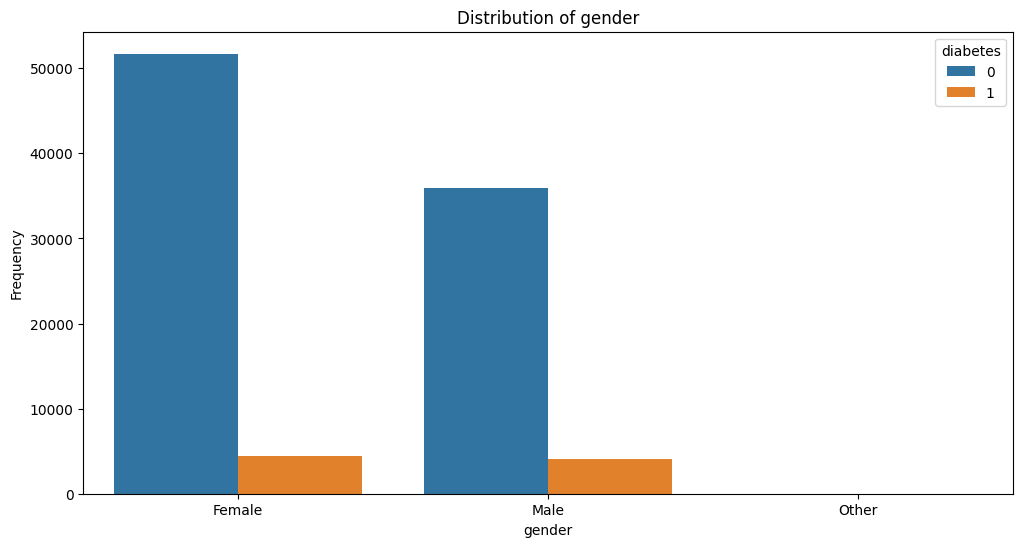

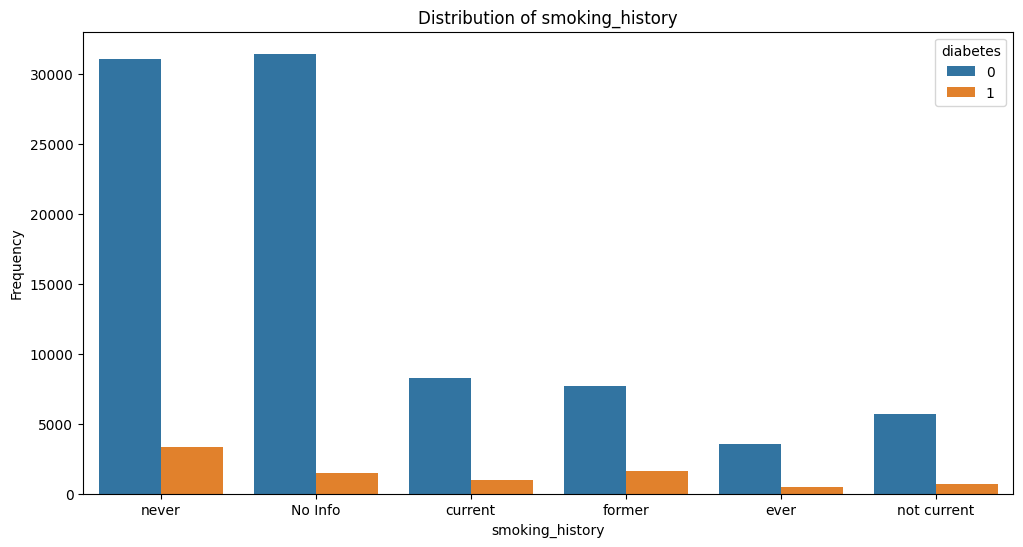

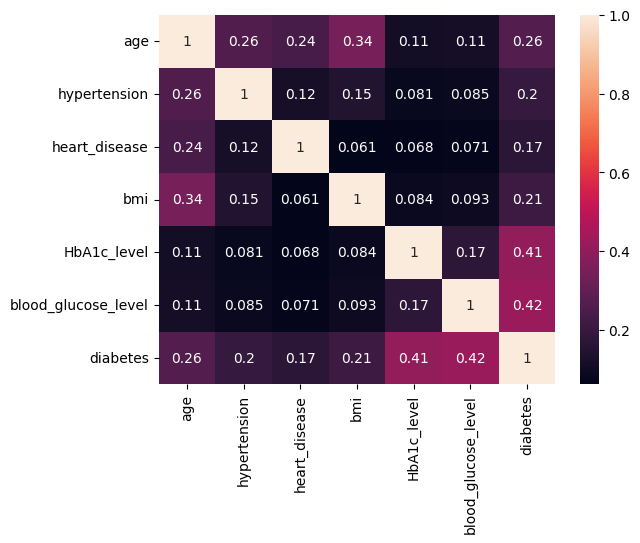

In [41]:
# extract the numerical and categorical features forom the data_copy_imputed dataframe
numerical_col_car_details = diabetes_prediction_dataset.select_dtypes(include=['int64', 'float64'])
categorical_col_car_details = diabetes_prediction_dataset.select_dtypes(include=['object'])


print('Numerical featurs EDA')
for i in numerical_col_car_details:
  fig = plt.figure(figsize=(12, 6))
  sns.boxplot(data=numerical_col_car_details, x=i)
  plt.xlabel(i)
  plt.ylabel('Frequency')
  plt.title(f'Distribution of {i}')
  plt.show()

print('Categorical featurs EDA')
for j in categorical_col_car_details:
  fig = plt.figure(figsize=(12, 6))
  sns.countplot(data=categorical_col_car_details, x=j , hue = diabetes_prediction_dataset['diabetes'])
  plt.xlabel(j)
  plt.ylabel('Frequency')
  plt.title(f'Distribution of {j}')
  plt.show()



# heatmap of numerical cols
sns.heatmap(numerical_col_car_details.corr(), annot=True)
plt.show()



### Observation for EDA

From the boxplot of the numerical features we can see that, features like ('age', 'bmi', 'HbA1c_level', and 'blood_glusoce_level') might have outliers. Hence, we will be using LOF on those features to find outliers.

From the countplot of the categorical features we can see that, the data set has most of the records with no diabetes. Thus, we can claim that the dataset is imbalanced an lack records for individuals with diabetes.

From the correlation matrix, we can see that no significant correlation among the features exist in the dataset.

### b. Outlier detection using LOF

In [30]:
### func to detect outlier and print
def find_outlier(df, col_name, n_neighbors=2500, contamination=0.01):
  ## Scaling the data
  scaler = StandardScaler()
  col_scaled = scaler.fit_transform(df[[col_name]])

  ## Adjusting LOF parameters
  lof = LocalOutlierFactor(n_neighbors = n_neighbors, contamination = contamination)  # Example adjustment
  outliers = lof.fit_predict(col_scaled)
  # print( outliers)
  ## Check the number of outliers detected
  outlier_count = np.sum(outliers == -1)
  print("Number of outliers detected:", outlier_count)


  ### Visualizing results
  plt.figure(figsize=(20, 10))
  plt.scatter(range(len(df[col_name])), df[col_name], c=outliers, cmap='coolwarm', label='Data Points')
  plt.colorbar()
  plt.title('Outlier Detection in ' + col_name)
  plt.xlabel('Index')
  plt.ylabel(col_name)
  plt.show()
  return outliers



### c. Process/Remove detected outliers
This function takes a dataframe as parameter and removes the detected outliers from the the dataframe.


In [ ]:

# data_copy_imputed_outlier_removed = data_copy_imputed.copy()
# data_copy_imputed_outlier_removed.info()
# count = 0
# for i in range(len(data_copy_imputed_outlier_removed)):
#   if outliers_mil[i] == -1 or outlier_year[i] == -1  or outliers_engine[i] == -1  or outliers_km[i] == -1 or outliers_max_power[i] == -1 or outliers_torque_nm[i] == -1 or outliers_torque_rpm[i] == -1:
#     count += 1
#     data_copy_imputed_outlier_removed.drop(data_copy_imputed_outlier_removed.index[i], inplace=True)

# print('Total rows dropped',count)
# data_copy_imputed_outlier_removed.info()

# def remove_outliers(df):
#   df_outlier_removed = df.copy()
#   df_outlier_removed = df_outlier_removed[df_outlier_removed['outlier'] != -1]
#   df_outlier_removed.drop(columns=['outlier'], inplace=True)
#   return df_outlier_removed

def remove_outliers_2(df, outlier_list):
  df_removed_outlier = df.copy()
  count = 0;
  for i in range (len(outlier_list)):
    if outlier_list[i] == -1:
      count += 1
      df_removed_outlier.drop(df_removed_outlier.index[i], inplace=True)
  print('Total rows dropped',count)
  return df_removed_outlier



## (d) Predictive analysis: Decision Trees

### a. Explore the DecisionTree classifier in scikit-learn

The DecisionTreeClassifier in scikit-learn is a versatile tool for building decision tree models for classification tasks. It works by recursively partitioning the data based on features to create a tree-like structure that predicts the class label of a given input.

### b. Explore the parameters (splitting criterion  (gini, entropy), max_depth, min_samples_split, etc) and choose a baseline setting

Choosing a baseline setting involves selecting initial values for the hyperparameters of the DecisionTreeClassifier. These hyperparameters influence the structure and behavior of the decision tree, affecting its performance. Here's a breakdown of some key hyperparameters and how to choose a baseline:

1. Splitting Criterion (criterion): measures the quality of a split.

*   **gini:** Measures the impurity of a node using Gini impurity. It's generally faster to compute.
*   **entropy:** Measures the impurity of a node using information gain. It can be more computationally intensive but might lead to slightly better performance in some cases.

2. Maximum Depth (max_depth):

*   Controls the maximum depth of the tree. Deeper trees can capture more complex relationships but are prone to overfitting.
*   If None, the tree is grown until all leaves are pure or until all leaves contain less than min_samples_split samples

3. Minimum Samples Split (min_samples_split):

*   The minimum number of samples required to split an internal node.
*   Can be an integer (the minimum number of samples) or a float (a fraction of the total number of samples).






In [31]:
### Baseline setting for DecisionTreeClassifier'
dt_model_baseline = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1)


## (e) Feature Engineering

### a. Feature construction

Two new features has been constructed.


*   **cardiovascular_risk_index**: aggregates risk factors for cardiovascular diseases. Indicators such as 'hypertension', 'heart disease' and 'BMI' have been summed up for this new feature. This feature could be an effective indicator for cardivascular risk calculation and hence also for diabetes prediction.
*   **metabolic _stress_score:** combines blood related metrics such as ' blood_glucose_level ' and
' HbA1c_level '. This feature can be effective for diagnosing metabolic syndrome and as a result can also be helpful for  prediction.




In [33]:

### func to create new featurs. Takes a datafarme as parameter and
### constructs two new feature using the existing features and
### returns a copy of the dataframe to the caller
def feature_engineering(df):
  df_copy = df.copy()
  # df_copy.info()
  # create the first new feature 'cardiovascular_risk_index'
  # this feature aggrigates risk factor for cardiovascular disease by
  #summing up the hypertension, heart_disease, BMI
  df_copy['cardiovascular_risk_index'] = df_copy['hypertension'] + df_copy['heart_disease'] + df['bmi']

  # create the second new feature 'metabolic_stress_score'
  # this feature combines blood related metric such as glucose and HbA1c levels,
  # which are critical for diagnosing diabetes and other metabolic syndromes.
  df_copy['metabolic_stress_score'] = df_copy['blood_glucose_level'] * df_copy['HbA1c_level']
  # df_copy.info()
  return df_copy



## (f) Empirical study

### a. Split dataset into 3 subset (train, validation and test)

Two subsets of the data; one for train and one for test has been explicitely splited and shown here. The third subset which is called validation set and used for validation purpose is done using the 4-fold cross validation. The cross validation makes 4 set of validation subsets by using 1/4 of the training data at each iteration of the validation process and use each one subset at a time.

In [37]:

### Removing the class imbalances from the dataset using undersampling technique
### create two dataframes one with class 0 and one with class 1 for target variable
#diab_data.drop(diab_data[diab_data['gender'] == 'Other'].index, inplace = True)
diab_class_0 = diabetes_prediction_dataset_encoded[diabetes_prediction_dataset_encoded['diabetes'] == 0]
diab_class_1 = diabetes_prediction_dataset_encoded[diabetes_prediction_dataset_encoded['diabetes'] == 1]


# Pick the same amount of random sample of class 1 from class 0
diab_class_0_under = diab_class_0.sample(diab_class_1.shape[0])   # take the number of rows correspoing to class_1
diab_data_under_sampled = pd.concat([diab_class_0_under, diab_class_1], axis = 0)



### split the dataset into 3 subset (DR,DT)
diab_data_encoded_train, diab_data_encoded_test = train_test_split(diab_data_under_sampled, test_size=0.2, random_state=42)
print("Traning subset: ", diab_data_encoded_train.shape)
print("Test subset: ", diab_data_encoded_test.shape)



Traning subset:  (13571, 15)
Test subset:  (3393, 15)


### b. Chosen evaluation metric

 Precision, Recall, and f1 score have been used for more comprehensive explanation. These metrics will be used for evaluating, comparing, and deciding the best final system.


In [38]:
evaluation_metric =  ['precision_macro', 'recall_macro','f1_macro']

### c. Baseline Model (encoded, with outliers, no feature construction)

As baseline, the DecisionTreeClassifier model with baseline settings has been used to initiate the model. To train the model, a dataset **without outlier removal** and **without new feature aggregation** has been used.


In [44]:
### copy the train set (DR) for baseline model
diab_data_encoded_baseline_train = diab_data_encoded_train.copy()
# diab_data_encoded_baseline_train.info()

### separate the predictor features and target feature
X_baseline_train = diab_data_encoded_baseline_train.drop(columns=['diabetes'])
y_baseline_train = diab_data_encoded_baseline_train['diabetes']

### Scale the dataset
scaler = StandardScaler()
numerical_col = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
### scale train data set (predictor features)
X_baseline_train[numerical_col] = scaler.fit_transform(X_baseline_train[numerical_col])

## cross validation
#dt_model_baseline = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1)
baseline_cv_scores = cross_validate(dt_model_baseline, X_baseline_train, y_baseline_train, cv=4, scoring=evaluation_metric)

baseline_precision_scores = baseline_cv_scores['test_precision_macro']
baseline_recall_scores = baseline_cv_scores['test_recall_macro']
baseline_f1_scores = baseline_cv_scores['test_f1_macro']

# print("Precision scores:", baseline_precision_scores)
# print("Recall scores:", baseline_recall_scores)
# print("F1 scores:", baseline_f1_scores)

print("###### Baseline Model (encoded, with outliers, no feature construction) ########")
print('mean_precision: ', np.mean(baseline_precision_scores))
print('mean_recall: ', np.mean(baseline_recall_scores))
print('mean_f1: ', np.mean(baseline_f1_scores))







###### Baseline Model (encoded, with outliers, no feature construction) ########
mean_precision:  0.8747384803484808
mean_recall:  0.8746546851380259
mean_f1:  0.87465128052267


### d. Other models
Different combinations of with/without dealing with outliers, with/without feature aggregation has been created for experiment. Using the chosen metric(s), evaluation of the different system versions on the validation set using a 4-fold cross-validation has been done. Based on these experiments, the best performing system will be chosen.

The model variations are as follows:


*   **Model 1:** encoded values, outlier removed, no new features construction
*   **Model 2:** encoded values, outliers removed, with new feature construction

*   **Model 3:** encoded values, with outliers, with new feature construction






### a. Model 1 (encoded, outlier removed, no new features construction)

Number of outliers detected: 14


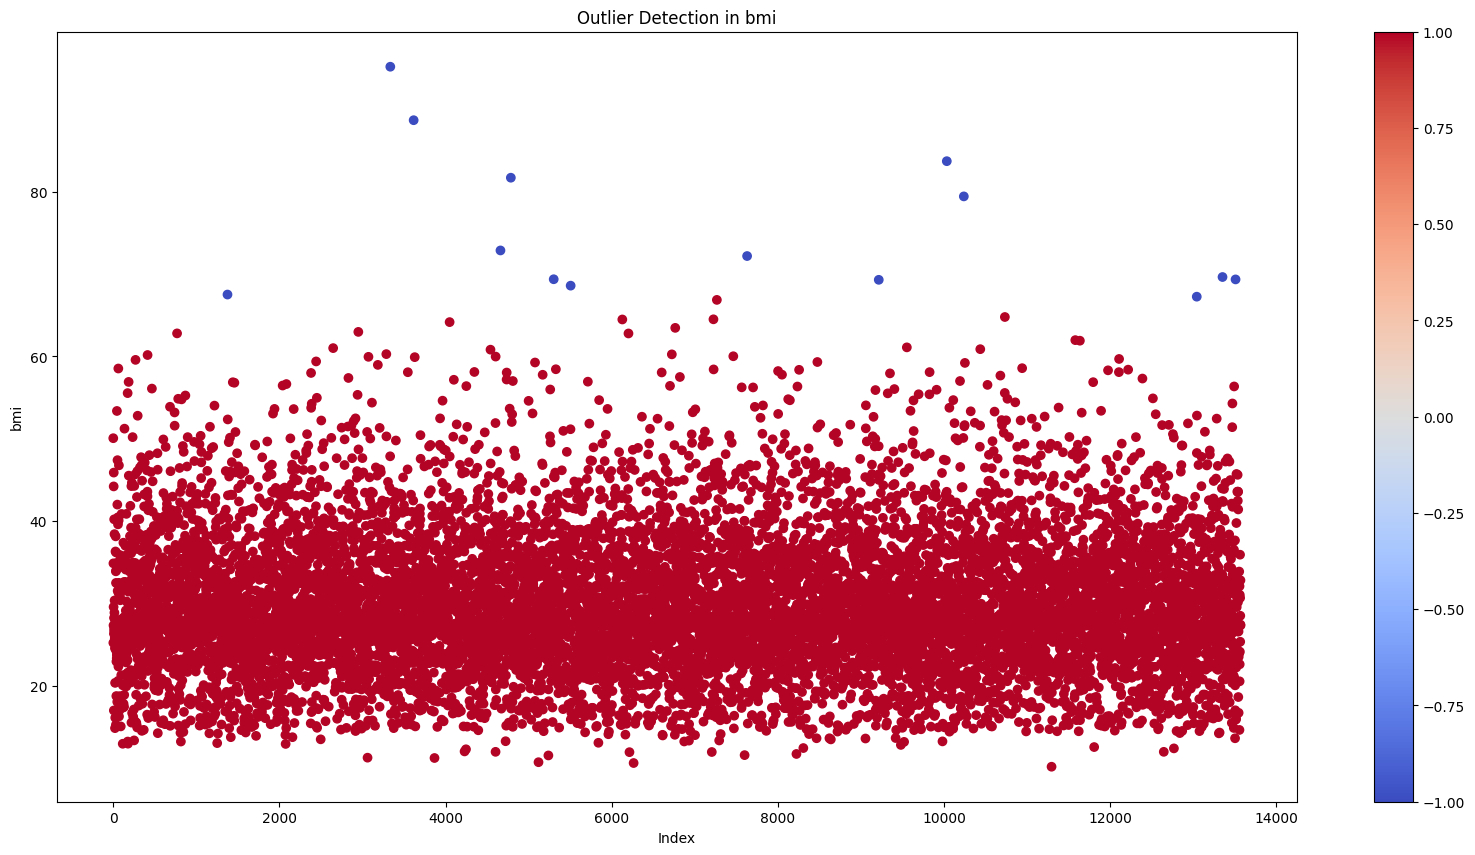

Number of outliers detected: 11


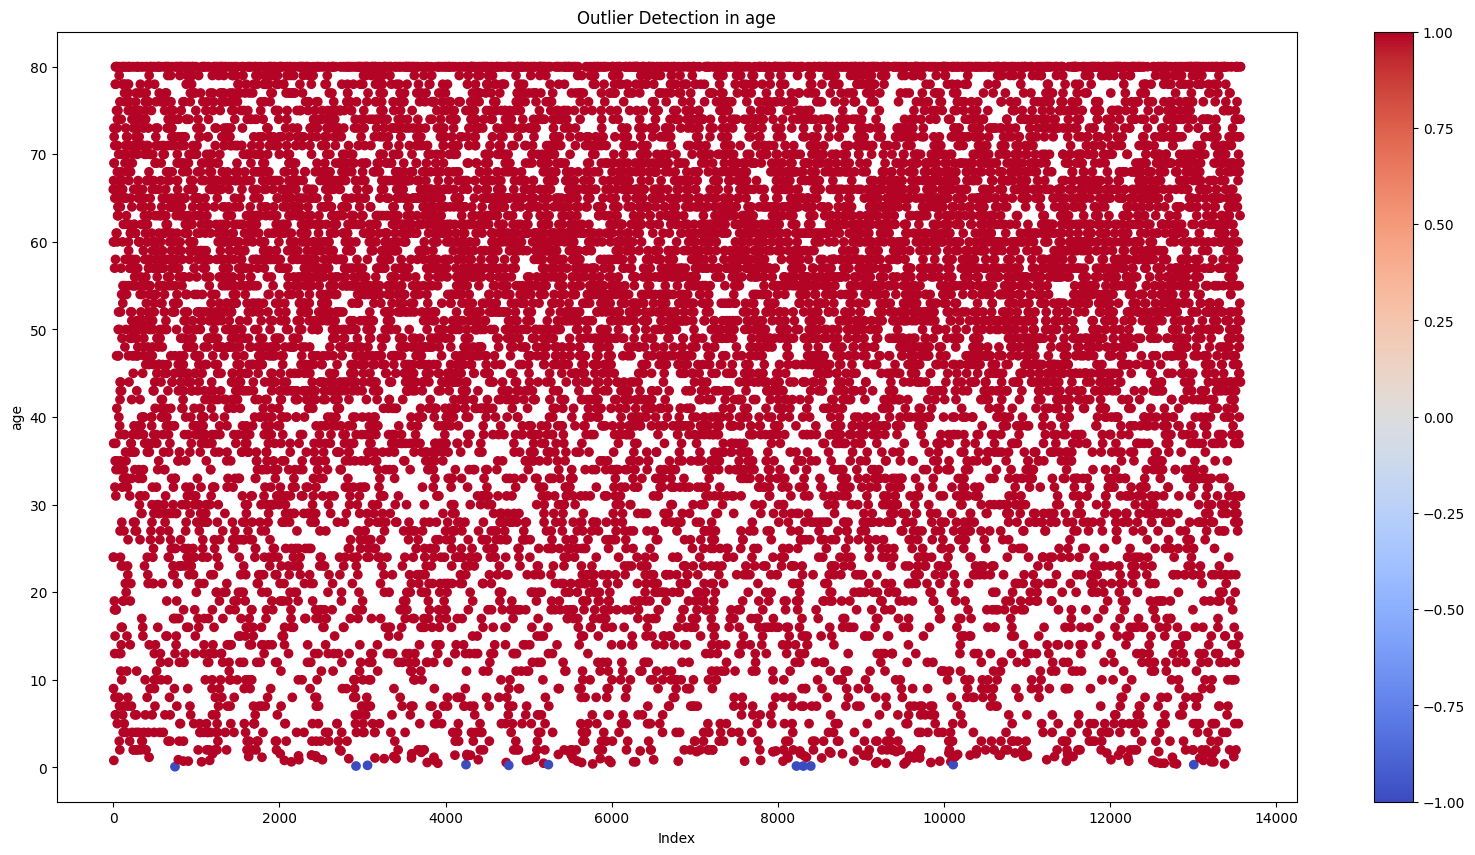

Number of outliers detected: 0


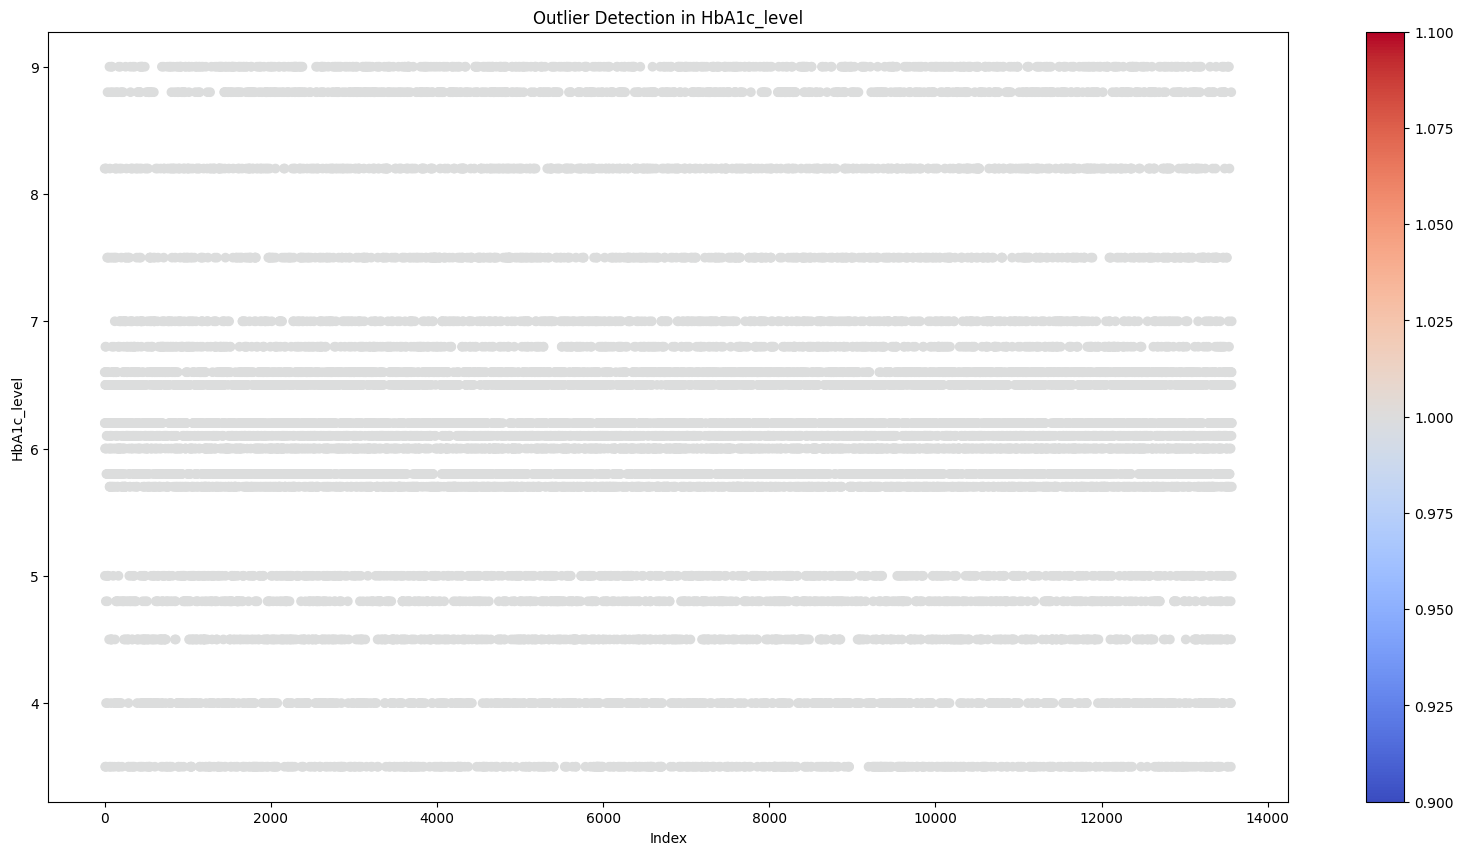

Number of outliers detected: 0


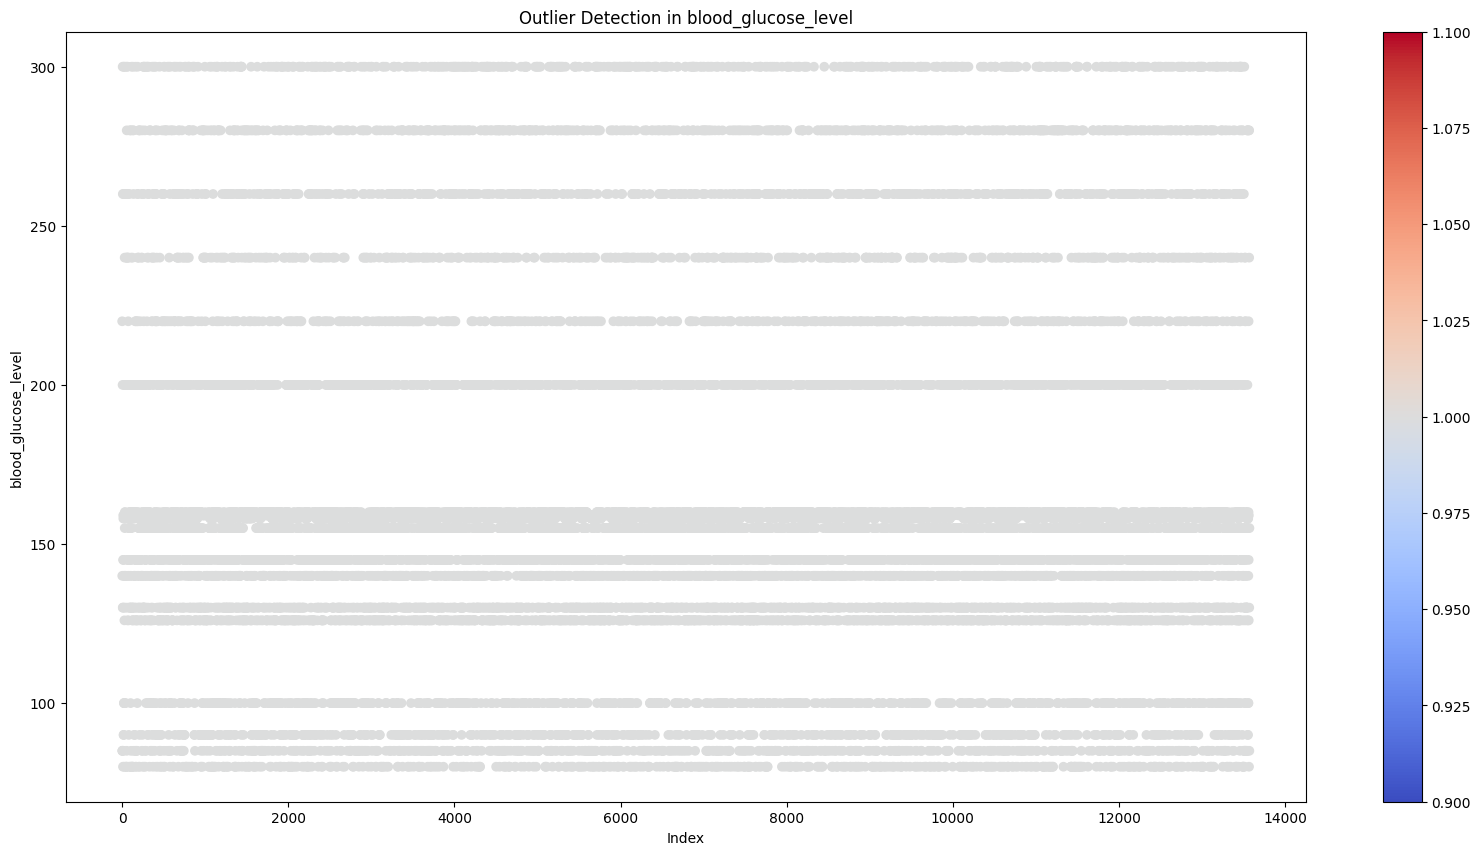

(13571, 15)
Total rows dropped 11
Total rows dropped 14
(13546, 15)
###### Model_1 (encoded, with outliers, no feature construction) ########
mean_precision:  0.8758536153594703
mean_recall:  0.8757547891007049
mean_f1:  0.875748235532476


In [43]:
### copy the train set (DR) for baseline model
diab_data_encoded_model_1_no_outlier_train = diab_data_encoded_train.copy()
# diab_data_encoded_model_1_no_outlier_train.info()


### remove outliers  age, bmi, HbA1c_level, blood_glucose_level
outliers_bmi = find_outlier(diab_data_encoded_model_1_no_outlier_train, 'bmi', 4500, 0.001)
outlier_age = find_outlier(diab_data_encoded_model_1_no_outlier_train, 'age',4500,0.001)
outliers_HbA1c_level = find_outlier(diab_data_encoded_model_1_no_outlier_train, 'HbA1c_level', 4000, 0.005)
outliers_blood_glucose_level = find_outlier(diab_data_encoded_model_1_no_outlier_train, 'blood_glucose_level', 4000,0.001)


### Outlier processing
print(diab_data_encoded_model_1_no_outlier_train.shape)
diab_data_encoded_model_1_outlier_removed_train = remove_outliers_2(diab_data_encoded_model_1_no_outlier_train, outlier_age)
diab_data_encoded_model_1_outlier_removed_train = remove_outliers_2(diab_data_encoded_model_1_outlier_removed_train, outliers_bmi)
print(diab_data_encoded_model_1_outlier_removed_train.shape)

## separate the predictor features and target feature
X_model_1_outlier_removed_train = diab_data_encoded_model_1_outlier_removed_train.drop(columns=['diabetes'])
y_model_1_outlier_removed_train = diab_data_encoded_model_1_outlier_removed_train['diabetes']


### Scale the dataset
scaler = StandardScaler()
numerical_col = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
## scale train data set (predictor features)
X_model_1_outlier_removed_train[numerical_col] = scaler.fit_transform(X_model_1_outlier_removed_train[numerical_col])


## cross validation
dt_model_1 = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1)
model_1_outlier_removed_cv_scores = cross_validate(dt_model_1, X_model_1_outlier_removed_train, y_model_1_outlier_removed_train, cv=4, scoring=evaluation_metric)

model_1_outlier_removed_precision_scores = model_1_outlier_removed_cv_scores['test_precision_macro']
model_1_outlier_removed_recall_scores = model_1_outlier_removed_cv_scores['test_recall_macro']
model_1_outlier_removed_f1_scores = model_1_outlier_removed_cv_scores['test_f1_macro']

# print("Precision scores:", model_1_outlier_removed_cv_scores)
# print("Recall scores:", model_1_outlier_removed_cv_scores)
# print("F1 scores:", model_1_outlier_removed_cv_scores)

print("###### Model_1 (encoded, with outliers, no feature construction) ########")
print('mean_precision: ', np.mean(model_1_outlier_removed_precision_scores))
print('mean_recall: ', np.mean(model_1_outlier_removed_recall_scores))
print('mean_f1: ', np.mean(model_1_outlier_removed_f1_scores))




### b. Model 2 (encoded values, outliers removed, with new feature construction)

In [45]:
### copy the outlier removed dataframe to 'diab_data_encoded_model_2_train'
diab_data_encoded_model_2_train = diab_data_encoded_model_1_outlier_removed_train.copy()

### feature construction
diab_data_model_2_outlier_removed_feature_eng_train = feature_engineering(diab_data_encoded_model_2_train)


## separate the predictor features and target feature
X_model_2_outlier_removed_feature_eng_train = diab_data_model_2_outlier_removed_feature_eng_train.drop(columns=['diabetes'])
y_model_2_outlier_removed_feature_eng_train = diab_data_model_2_outlier_removed_feature_eng_train['diabetes']


### Scale the dataset
scaler = StandardScaler()
numerical_col = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level','cardiovascular_risk_index','metabolic_stress_score']
### scale train data set (predictor features)
X_model_2_outlier_removed_feature_eng_train[numerical_col] = scaler.fit_transform(X_model_2_outlier_removed_feature_eng_train[numerical_col])



### DecisionClassifier
dt_model_2 = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1)

### cross validation
#dt_model_baseline = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1)
model_2_outlier_removed_feature_eng_cv_scores = cross_validate(dt_model_2, X_model_2_outlier_removed_feature_eng_train, y_model_2_outlier_removed_feature_eng_train, cv=4, scoring=evaluation_metric)

model_2_outlier_removed_feature_eng_precision_scores = model_2_outlier_removed_feature_eng_cv_scores['test_precision_macro']
model_2_outlier_removed_feature_eng_recall_scores = model_2_outlier_removed_feature_eng_cv_scores['test_recall_macro']
model_2_outlier_removed_feature_eng_eng_f1_scores = model_2_outlier_removed_feature_eng_cv_scores['test_f1_macro']

print("########### Model 2: encoded values, outliers removed, with new feature construction #############")
# print("Precision scores:", model_2_outlier_removed_feature_eng_precision_scores)
# print("Recall scores:", model_2_outlier_removed_feature_eng_recall_scores)
# print("F1 scores:", model_2_outlier_removed_feature_eng_eng_f1_scores)

print('mean_precision: ', np.mean(model_2_outlier_removed_feature_eng_precision_scores))
print('mean_recall: ', np.mean(model_2_outlier_removed_feature_eng_recall_scores))
print('mean_f1: ', np.mean(model_2_outlier_removed_feature_eng_eng_f1_scores))



########### Model 2: encoded values, outliers removed, with new feature construction #############
mean_precision:  0.8759038162126693
mean_recall:  0.8758313694925693
mean_f1:  0.8758241157988897


### Model 3 (encoded values, with outliers, with new feature construction)

In [46]:
## copy the train set (DR) for model3
diab_data_model_3_feature_eng_train = diab_data_encoded_train.copy()

### feature construction
diab_data_model_3_feature_eng_train = feature_engineering(diab_data_model_3_feature_eng_train)
#diab_data_model_3_feature_eng_train.info()

## separate the predictor features and target feature
X_model_3_feature_eng_train = diab_data_model_3_feature_eng_train.drop(columns=['diabetes'])
y_model_3_feature_eng_train = diab_data_model_3_feature_eng_train['diabetes']


### Scale the dataset
scaler = StandardScaler()
numerical_col = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level','cardiovascular_risk_index','metabolic_stress_score']
## scale train data set (predictor features)
X_model_3_feature_eng_train[numerical_col] = scaler.fit_transform(X_model_3_feature_eng_train[numerical_col])


### DecisionClassifier
dt_model_3 = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1)

### cross validation
#dt_model_baseline = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1)
model_3_feature_eng_cv_scores = cross_validate(dt_model_3, X_model_3_feature_eng_train, y_model_3_feature_eng_train, cv=4, scoring=evaluation_metric)

model_3_feauter_eng_precision_scores = model_3_feature_eng_cv_scores['test_precision_macro']
model_3_feauter_eng_recall_scores = model_3_feature_eng_cv_scores['test_recall_macro']
model_3_feauter_eng_f1_scores = model_3_feature_eng_cv_scores['test_f1_macro']

print(" ########### Model 3 :encoded values, with outliers, with new feature construction ###########")
# print("Precision scores:", model_3_feauter_eng_precision_scores)
# print("Recall scores:", model_3_feauter_eng_recall_scores)
# print("F1 scores:", model_3_feauter_eng_f1_scores)

print('mean_precision: ', np.mean(model_3_feauter_eng_precision_scores))
print('mean_recall: ', np.mean(model_3_feauter_eng_recall_scores))
print('mean_f1: ', np.mean(model_3_feauter_eng_f1_scores))








 ########### Model 3 :encoded values, with outliers, with new feature construction ###########
mean_precision:  0.8756256050807941
mean_recall:  0.8755421636006013
mean_f1:  0.8755364637766717


### e. Model comparison

Model_2 (encoded values, outliers removed, with new feature construction) is the best performing model among the 4 models.
The comparative overview of the evaluation metric for Model_2 is as follows:


*   **Precision:** Model 2 has the highest mean precision (0.87590), indicating it makes the fewest false positive errors among the models.

*   **Recall:** Model 2 also leads in recall (0.87583), suggesting it is best at identifying all relevant cases.
*   **F1 Score:** Consistent with precision and recall, Model 2 achieves the highest F1 score (0.87582), which is a balanced measure combining precision and recall.


Model 2 outperforms the others across all three metrics, making it the best model among those listed. The removal of outliers and the construction of new features appear to have positively influenced its performance compared to the other models.

In [ ]:
### use test set on model2 for final evaluation
X_best_train = X_model_2_outlier_removed_feature_eng_train
y_best_train = y_model_2_outlier_removed_feature_eng_train

diab_data_encoded_test = feature_engineering(diab_data_encoded_test)

dt_best_model = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1)


X_test = diab_data_encoded_test.drop(columns=['diabetes'])
y_test = diab_data_encoded_test['diabetes']



### Scale the dataset
scaler = StandardScaler()
numerical_col = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
## scale train data set (predictor features)
X_test[numerical_col] = scaler.fit_transform(X_test[numerical_col])


dt_best_model.fit(X_best_train, y_best_train)
dt_y_pred = dt_best_model.predict(X_test)


print('### Test results for Decision Tree Calssifier Default ###')
print('Accuracy:', accuracy_score(y_test, dt_y_pred))
print('Precision Score:' , precision_score(y_test, dt_y_pred))
print('Recall score:' , recall_score(y_test, dt_y_pred))
print('F1 Score:' , f1_score(y_test, dt_y_pred))


### Test results for Decision Tree Calssifier Default ###
Accuracy: 0.6604774535809018
Precision Score: 0.595561918396564
Recall score: 0.9869513641755635
F1 Score: 0.7428571428571429


## Result Analysis ##


*   **Obtained result analysis:**

  **Model_2** outperforms the other models across all three key metrics (precision, recall, and F1 score), establishing it as the superior model in this study. This analysis utilized different combinations of data preprocessing techniques, such as handling outliers and constructing new features, to optimize classification performance.

  The Baseline Model was the least effective, likely because it was trained on less pre-processed data. This limited its ability to discern complex patterns and relationships among the dataset's features. In contrast, **Model_2** benefited significantly from both the removal of outliers and the introduction of new features. These steps enhanced its ability to learn and model the intricate relationships within the data more effectively.
  
*   **Impact of Outlier Detection and Feature Construction:**

  Removing outliers proved beneficial by eliminating extreme data points that occur infrequently, which could otherwise lead to a model biased by these anomalies. Additionally, constructing new features enabled the discovery of more intricate patterns within the data, which might not have been captured by the original features alone. Both outlier removal and feature construction were pivotal in enhancing the model's performance.

*   **Evaluation on Test Data:**

  The evaluation metrics for the test data were slightly lower than those for **Model_2** during cross-validation, which is expected. Testing on unseen data typically yields lower scores if the model generalizes well. Conversely, significantly higher scores on test data might indicate overfitting. This disparity underscores the importance of rigorous testing to ensure the model's robustness in real-world scenarios.





## References

* https://github.com/PacktPublishing/Data-Cleaning-and-Exploration-with-Machine-Learning/blob/main/7.%20LinearRegression/1.%20linear_regression.py

* https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


* https://stackoverflow.com/questions/68057640/do-we-expect-baseline-all-features-and-selected-features-to-perform-the-same-w

* https://medium.com/@ananthsgouri/building-your-first-machine-learning-model-with-pythons-scikit-learn-37bccb5281bd







